In [1]:
import logging
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold

from un_general_debate_analysis.external import load_all
from un_general_debate_analysis.preprocessing import OUT_DIR

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # no "semibold" font in some setups
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# one palette for the whole notebook (same as the other SDG 9 notebooks)
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#dddcd7"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
DIVERGING = LinearSegmentedColormap.from_list("bark_byte", [ORANGE, "#ffffff", BLUE])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 2.0, "font.size": 10,
})


def finish(ax, title=None, subtitle=None, xlabel=None, ylabel=None, legend=False, grid="y"):
    """Title, optional subtitle, axis labels and a recessive grid, applied the same way everywhere."""
    if title:
        ax.set_title(title, pad=16 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes, fontsize=8.5, color=INK_SOFT, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_axisbelow(True)
    ax.grid(False)
    if grid:
        ax.grid(True, axis=grid)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")
    return ax


def zscore(s):
    return (s - s.mean()) / s.std()


def mean_ci(g, col):
    """Mean and 95% half-width of ``col`` within each group of a groupby."""
    a = g[col].agg(["mean", "std", "count"])
    a["ci"] = 1.96 * a["std"] / np.sqrt(a["count"])
    return a

## 1. Data and measures

In [2]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
external = load_all(verbose=False) # World Bank + WHR + EGDI, keyed on (country_code, year)

DI, IA = "digital_infrastructure", "internet_and_access" # use it for shorter labels
speech = features[["country_code", "country", "year", "region_name", "n_sentences"]].copy()

n_di, n_ia = features[f"{DI}_sentences"], features[f"{IA}_sentences"]
speech["dig_n"] = n_di + n_ia # digital sentences (pooled)
speech["mention"] = (speech["dig_n"] > 0).astype(int) # said anything digital? use it a flag
speech["salience"] = speech["dig_n"] / speech["n_sentences"] # topic share
said = speech["dig_n"].where(speech["dig_n"] > 0) # NaN when nothing was said
speech["sentiment"] = (n_di * features[f"{DI}_sentiment"] + n_ia * features[f"{IA}_sentiment"]) / said # avg sentiment
speech["promise"] = (features[f"{DI}_frame_promise_sentences"] + features[f"{IA}_frame_promise_sentences"]) / said

# Merge all data together
panel = speech.merge(external, on=["country_code", "year"], how="left")


# as LEAD function, get the metrics k years in the future 
def lead(col, k, name):
    s = external[["country_code", "year", col]].copy()
    s["year"] -= k
    return s.rename(columns={col: name})


# a speech is delivered in year t so t -> t+1 is the first full year after it.
# LEAD for internet users and mobile
for col, short in [("internet_users_pct", "internet"), ("mobile_per_100", "mobile")]:
    panel = panel.merge(lead(col, 1, f"{short}_t1"), on=["country_code", "year"], how="left")
    panel[f"{short}_gain_next"] = panel[f"{short}_t1"] - panel[col] # percentage points / subs per 100

panel["log_gdp"] = np.log(panel["gdp_per_capita_ppp"])
modern = panel[panel["year"].between(2005, 2024)].copy() # 2025 has no connectivity data yet

print(f"{len(modern):,} speeches, {modern['country_code'].nunique()} countries, {modern['year'].min()}-{modern['year'].max()}")
print(f"{modern['mention'].sum():,} speeches ({modern['mention'].mean():.0%}) contain at least one digital sentence; "
      f"median number of such sentences when they do: {modern.loc[modern['mention'] == 1, 'dig_n'].median():.0f}")
modern[["mention", "salience", "sentiment", "promise", "internet_users_pct", "mobile_per_100",
        "internet_gain_next", "perceived_corruption"]].describe().T[["count", "mean", "std", "min", "50%", "max"]]

3,857 speeches, 197 countries, 2005-2024
1,000 speeches (26%) contain at least one digital sentence; median number of such sentences when they do: 1


,count,mean,std,min,50%,max
mention,"3,857.000",0.259,0.438,0.000,0.000,1.000
salience,"3,857.000",0.005,0.012,0.000,0.000,0.159
sentiment,"1,000.000",0.281,0.453,-0.988,0.362,0.976
promise,"1,000.000",0.206,0.361,0.000,0.000,1.000
internet_users_pct,"3,661.000",45.958,31.710,0.065,44.875,100.000
mobile_per_100,"3,707.000",93.352,43.853,0.000,100.333,574.152
internet_gain_next,"3,457.000",2.722,3.284,-20.927,2.000,40.444
perceived_corruption,"2,169.000",0.746,0.183,0.035,0.799,0.983


**Most speeches say nothing digital, and those that do say very little.** About one speech in four (26%) contains a digital sentence and the median is a single sentence, so a speech's "sentiment" is usually the VADER score of *one* sentence. That is noisy, and it shapes the design: sentiment only exists when a country spoke, so the plots below either use the speeches that say something or use measures defined for every speech (mention, salience).

## 2. Q1 - Exploratory: does the tone of digital talk track connectivity?

### 2.1 Bark and byte over time

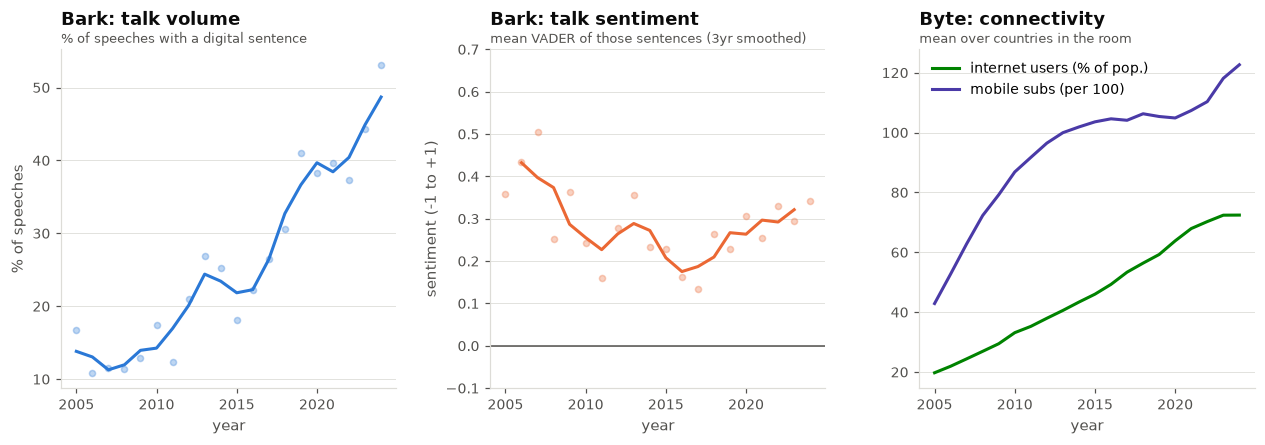

2005-09 -> 2020-24:
talk      13% -> 43% of speeches
sentiment 0.38 -> 0.31
internet  25% -> 69%
mobile    62 -> 113 per 100


In [3]:
# calculate yearly
yr = (modern.groupby("year").agg(talk=("mention", "mean"), 
                                sentiment=("sentiment", "mean"),
                                internet=("internet_users_pct", "mean"), 
                                mobile=("mobile_per_100", "mean"))
                            .query("year >= 2000 and year <= 2024")) # our period of interest, internet is a thing
# take rolling for smoothness
yr["talk_s"] = yr["talk"].rolling(3, center=True, min_periods=2).mean()
yr["sent_s"] = yr["sentiment"].rolling(3, center=True, min_periods=3).mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, gridspec_kw={"wspace": 0.28})

ax = axes[0]
ax.plot(yr.index, 100 * yr["talk"], "o", color=BLUE, alpha=0.3, ms=4)
ax.plot(yr.index, 100 * yr["talk_s"], color=BLUE)
finish(ax, "Bark: talk volume", "% of speeches with a digital sentence", ylabel="% of speeches")

ax = axes[1]
ax.axhline(0, color=INK_SOFT, lw=1)
ax.plot(yr.index, yr["sentiment"], "o", color=ORANGE, alpha=0.3, ms=4)
ax.plot(yr.index, yr["sent_s"], color=ORANGE)
ax.set_ylim(-0.1, 0.7)
finish(ax, "Bark: talk sentiment", "mean VADER of those sentences (3yr smoothed)", ylabel="sentiment (-1 to +1)")

ax = axes[2]
ax.plot(yr.index, yr["internet"], color=GREEN, label="internet users (% of pop.)")
ax.plot(yr.index, yr["mobile"], color=VIOLET, label="mobile subs (per 100)")
finish(ax, "Byte: connectivity", "mean over countries in the room", legend=True)

for ax in axes:
    ax.set_xlabel("year")
plt.show()


era_gap = yr.mean() - yr.mean()
print(f"2005-09 -> 2020-24:\n"
      f"talk      {100*yr.loc[2005:2009, 'talk'].mean():.0f}% -> {100*yr.loc[2020:2024,'talk'].mean():.0f}% of speeches\n"
      f"sentiment {yr.loc[2005:2009, 'sentiment'].mean():.2f} -> {yr.loc[2020:2024, 'sentiment'].mean():.2f}\n"
      f"internet  {yr.loc[2005:2009, 'internet'].mean():.0f}% -> {yr.loc[2020:2024, 'internet'].mean():.0f}%\n"
      f"mobile    {yr.loc[2005:2009, 'mobile'].mean():.0f} -> {yr.loc[2020:2024, 'mobile'].mean():.0f} per 100")

**The volume of talk and the connectivity of the world rise together; the tone does not follow.** Between 2005-09 and 2020-24 the share of speeches with a digital sentence goes from 13% to 43% (and reaches 53% in 2024), internet use in the countries in the room from 25% to 69% of the population and mobile subscriptions from 62 to 113 per 100 people. Average sentiment ends up close to where it started (0.38 to 0.31), but it does not move steadily: it falls from about 0.4 in 2006-07 to a low of about 0.18 around 2016 and then recovers to about 0.3. That is a dip and a rebound, not a trend that tracks connectivity, and the year-to-year wobble is the noise of a few hundred one-sentence scores. Two shared upward lines are a coincidence of timelines rather than evidence of a link, so the next plots compare countries *within* the same period.

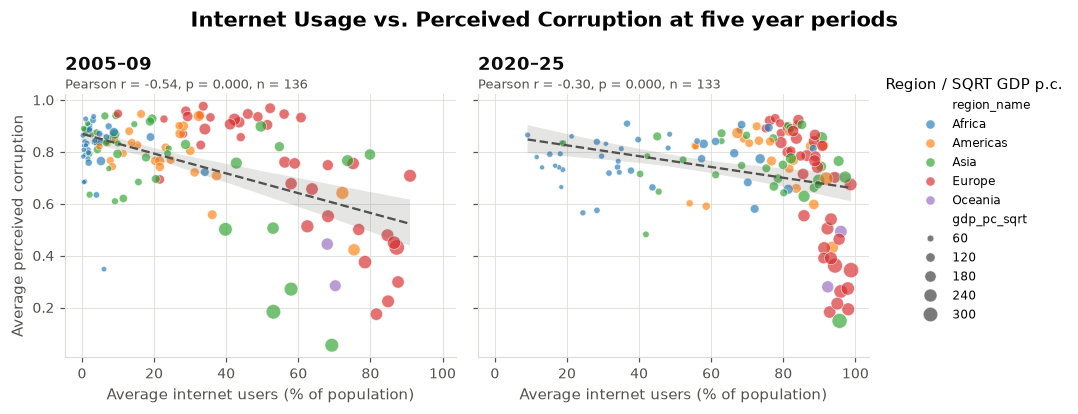

In [4]:
periods = ["2005–09", "2020–25"]

data = (modern.query("(year >= 2005 and year <= 2009) or (year >= 2020 and year <= 2025)")
    [["country_code", "region_name", "year", "internet_users_pct", "perceived_corruption", "whr_log_gdp_pc"]]
    .dropna(subset=["internet_users_pct", "perceived_corruption"]).copy())

data["gdp_pc"] = np.exp(data["whr_log_gdp_pc"])
data["gdp_pc_sqrt"] = np.sqrt(np.exp(data["whr_log_gdp_pc"]))

data["period"] = data["year"].apply(lambda y: periods[0] if y <= 2009 else periods[1])

period_data = (
    data.groupby(["period", "country_code", "region_name"], observed=True)
    [["internet_users_pct", "perceived_corruption", "gdp_pc_sqrt"]]
    .mean()
    .reset_index()
)

hue_order = sorted(period_data["region_name"].unique())
palette = dict(zip(hue_order, sns.color_palette(n_colors=len(hue_order))))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, period in zip(axes.flat, periods):
    subset = period_data[period_data["period"].eq(period)]

    sns.scatterplot(data=subset, x="internet_users_pct", y="perceived_corruption",
                    hue="region_name", hue_order=hue_order, palette=palette,
                    size="gdp_pc_sqrt", sizes=(10, 100), alpha=0.65,
                    edgecolor="white", linewidth=0.5, ax=ax,
                    legend=(period == periods[0]),
    )

    subtitle = ""
    if len(subset) > 1:
        sns.regplot(data=subset, x="internet_users_pct", y="perceived_corruption",
                    scatter=False, color=INK_SOFT, line_kws={"linestyle": "--", "linewidth": 1.5},
                    ax=ax,
        )
        rho, p = stats.pearsonr(subset["internet_users_pct"], subset["perceived_corruption"])
        subtitle = f"Pearson r = {rho:+.2f}, p = {p:.3f}, n = {len(subset)}"

    finish(ax, f"{period}", subtitle, xlabel="Average internet users (% of population)",
        ylabel="Average perceived corruption" if ax in axes else "", grid="both",
    )

handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].legend_.remove()
fig.suptitle("Internet Usage vs. Perceived Corruption at five year periods", fontsize=14, fontweight="bold", y=0.93)

fig.legend(handles, labels, loc="center left",
    bbox_to_anchor=(0.8, 0.5), fontsize=8, title="Region / SQRT GDP p.c.", frameon=False,
)

plt.tight_layout(rect=[0, 0, 0.81, 0.95])
plt.savefig("corruption_it_usage", bbox_inches="tight")
plt.show()

**Better-connected countries are perceived as less corrupt, but the pattern is weaker in the later period and is largely about income.** Across countries, more internet use goes with lower perceived corruption in both periods (Pearson r = -0.54 in 2005-09, r = -0.30 in 2020-25, both p < 0.001, n = 136 and 133). The slope flattens because most countries have caught up: in 2020-25 the bulk sit between roughly 60% and 100% online with corruption scores of 0.6-0.9, and the fitted line is pulled down by a cluster of rich, mostly European countries in the bottom right. The point size (income) and the heatmap below suggest that income is doing much of the work, so this is a link between internet use and corruption via wealth, not evidence that connectivity reduces corruption.

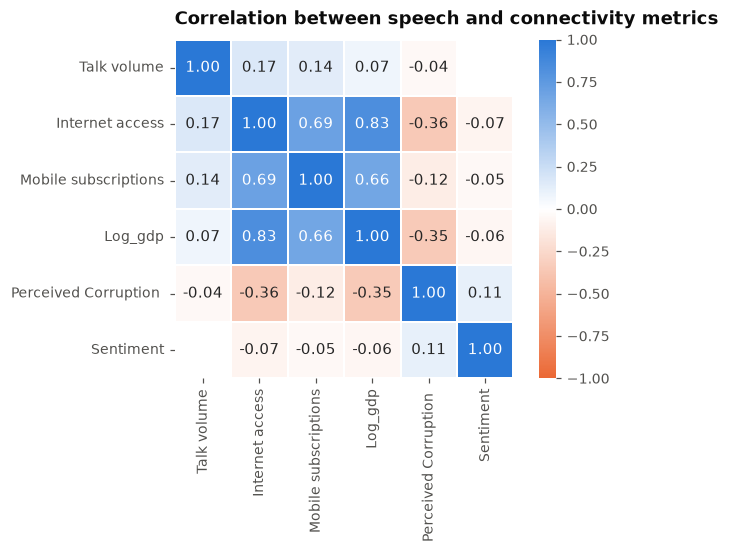

In [5]:
metrics = (modern
    .query('year >= 2005 and year <= 2025')
    .groupby(['year', 'country_code'])
    .agg(
        talk=("mention", "mean"),
        sentiment=("sentiment", "mean"),
        internet=("internet_users_pct", "mean"), 
        mobile=("mobile_per_100", "mean"),
        corruption=("perceived_corruption", "mean"),
        gdp=("whr_log_gdp_pc","mean"))
)
metrics = metrics.rename(columns={
    "talk": "Talk volume",
    "sentiment": "Sentiment",
    "internet": "Internet access",
    "mobile": "Mobile subscriptions",
    "corruption" : "Perceived Corruption ",
    "gdp": "Log_gdp"
})

# Pearson correlations
corr = metrics.corr(method="pearson")
corr = corr.sort_values('Talk volume', ascending=False)
corr = corr[corr.index]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1,
    center=0, square=True, linewidths=1, linecolor="white", ax=ax,)

finish(ax, "Correlation between speech and connectivity metrics", grid=None)
plt.show()

**The heatmap agrees with the time series: talk volume relates weakly to connectivity, and sentiment hardly relates to anything.** Talk volume has a small positive correlation with internet access (+0.17) and mobile subscriptions (+0.14), both statistically significant given the sample size (n about 3,700) but explaining only 2-3% of the variance, and essentially none with perceived corruption (-0.04). Sentiment is even weaker: -0.07 with internet access (p = 0.02), -0.05 with mobile subscriptions (p = 0.16) and -0.06 with log GDP (p = 0.13), based on the roughly 950 country-years that say something digital. The one exception, +0.11 with perceived corruption (p = 0.006, n = 588), is fragile: it is not significant as a rank correlation (Spearman +0.06, p = 0.15) and is small, so it is a hint rather than a finding. The cell for talk volume and sentiment is blank because sentiment only exists when a country spoke about digital topics, so talk volume is constant (always 1) in that subset and a correlation cannot be computed. Internet access, mobile subscriptions and GDP are strongly correlated with each other (0.66-0.83), so they mostly carry the same information.

### Q1 in short

* **Volume moves with connectivity; tone does not.** Digital talk becomes far more common as the world gets connected (13% of speeches in 2005-09 to 43% in 2020-24, as internet use goes from 25% to 69%), but average sentiment stays around +0.3. It dips to about +0.2 in the mid-2010s and recovers, without following connectivity.
* **Across countries, tone and connectivity are essentially unrelated** (Pearson r = -0.07 with internet use, -0.05 with mobile subscriptions; only the first is nominally significant, and both explain under 1% of the variance). If anything, better-connected countries sound slightly *cooler*. Talk *volume* is the part that relates to connectivity (r = +0.14 to +0.17), and even that is weak.
* **Internet use and perceived corruption are negatively related** (r = -0.54 in 2005-09, -0.30 in 2020-25), but this overlaps heavily with income, and sentiment shows no reliable relation to corruption (r = +0.11, not robust to a rank test).
* **So the exploratory answer to "all bark, no byte?" is that bark and byte are simply uncorrelated in tone.** Positive digital rhetoric is not a marker of connected countries.

## 3. Q2 - Predictive: does sentiment forecast next year's gain, and does corruption matter?

### 3.1 Design

* **Target:** `internet_gain_next`, the change in % of the population online from year `t` to `t+1` (percentage points).
* **Unit:** a speech (country-year), 2005-2023, restricted to speeches whose country has a corruption score, a GDP figure and a next-year internet value.
* **Speech features:** whether the country mentioned digital topics, the topic share, the sentiment and the promise framing. Sentiment and framing are set to 0 (neutral) when nothing was said, and the mention flag lets a model tell "silent" from "neutral".
* **Context features in every model:** internet level at `t`, its square, log GDP per capita and the year. Adoption follows an S-curve, so *where a country is on the curve* is the obvious predictor of its next gain, and the speeches have to add to *that*.
* **Two models:** a regularised linear model (Ridge) and a random forest, so the relationship can be linear or non-linear.
* **Validation:** repeated 5-fold cross-validation that **holds out whole countries**, so a model cannot look up a country's own history.

2,113 speeches from 150 countries, 2005-2023; 574 of them contain digital talk
mean next-year gain 2.76 pp (sd 3.39)


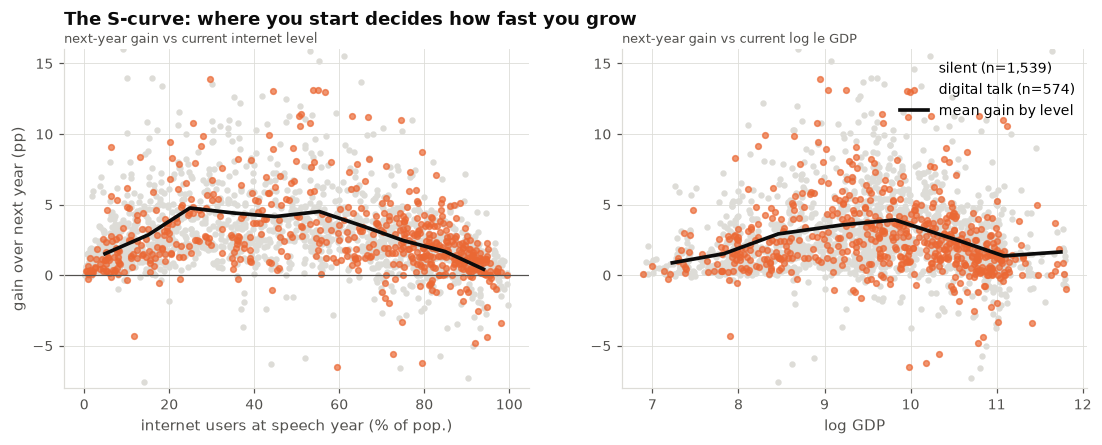

In [6]:
q2 = (panel[panel["year"].between(2005, 2023)]
      .dropna(subset=["internet_gain_next", "perceived_corruption", "internet_users_pct", "log_gdp"]).copy())


print(f"{len(q2):,} speeches from {q2['country_code'].nunique()} countries, {q2['year'].min()}-{q2['year'].max()}; "
      f"{q2['mention'].sum()} of them contain digital talk")
print(f"mean next-year gain {q2['internet_gain_next'].mean():.2f} pp (sd {q2['internet_gain_next'].std():.2f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

quiet, talk = q2[q2["mention"] == 0], q2[q2["mention"] == 1]
ax[0].scatter(quiet["internet_users_pct"], quiet["internet_gain_next"], s=10, color=GRID, label=f"silent (n={len(quiet):,})")
ax[0].scatter(talk["internet_users_pct"], talk["internet_gain_next"], s=14, color=ORANGE, alpha=0.7, label=f"digital talk (n={len(talk):,})")

bins = pd.cut(x=q2["internet_users_pct"], bins=np.arange(0, 101, 10), include_lowest=True)
curve = q2.groupby(bins, observed=True).agg(x=("internet_users_pct", "mean"), y=("internet_gain_next", "mean"))
ax[0].plot(curve["x"], curve["y"], color=INK, lw=2.4, label="mean gain by level")
ax[0].axhline(0, color=INK_SOFT, lw=0.8)
ax[0].set_ylim(-8, 16)
finish(ax[0], "The S-curve: where you start decides how fast you grow",
       "next-year gain vs current internet level", xlabel="internet users at speech year (% of pop.)",
       ylabel="gain over next year (pp)", grid="both")

ax[1].scatter(quiet["log_gdp"], quiet["internet_gain_next"], s=10, color=GRID, label=f"silent (n={len(quiet):,})")
ax[1].scatter(talk["log_gdp"], talk["internet_gain_next"], s=14, color=ORANGE, alpha=0.7, label=f"digital talk (n={len(talk):,})")

mn = int(q2["log_gdp"].min())
mx = int(q2["log_gdp"].max()) + 2
diff = mx - mn
bins = pd.cut(x=q2["log_gdp"], bins=np.arange(mn, mx, diff/10), include_lowest=True)
curve = q2.groupby(bins, observed=True).agg(x=("log_gdp", "mean"), y=("internet_gain_next", "mean"))
ax[1].plot(curve["x"], curve["y"], color=INK, lw=2.4, label="mean gain by level")
ax[1].set_ylim(-8, 16)

finish(ax[1], "",
       "next-year gain vs current log le GDP", xlabel="log GDP",
       ylabel="", grid="both")
ax[1].legend(loc="upper right")


plt.show()

Three things to take from the pictures. **Next year's gain is mostly a function of where a country already is**: gains are largest (about 4-5 pp) between roughly 20% and 60% online and shrink towards saturation, to under 1 pp above 90% (so the context features will do a lot of work). **Income tells the same story, but not as a straight line**: mean gain rises with log GDP to about 4 pp in the middle of the range and falls back to about 1.4 pp for the richest countries, which are already mostly online (log GDP and internet use correlate at 0.83, and the linear correlation of log GDP with next-year gain is about 0). And **digital talk is spread all along both curves** rather than concentrated at one end; it is a little more common in low-corruption countries (about 30% of speeches vs 24% in the high-corruption tercile), which is a first hint that corruption relates to the talk itself.

### 3.2 Feature sets and models

In [7]:
CONTEXT = ["internet_users_pct", "internet_sq", "log_gdp"]
SENT = ["sentiment_f"]
TALK = ["mention", "salience", "promise_f"]
CORR = ["perceived_corruption"]


q2["internet_sq"] = q2["internet_users_pct"] ** 2 / 100
q2["sentiment_f"] = q2["sentiment"].fillna(0)
q2["promise_f"] = q2["promise"].fillna(0)

z = q2.copy()
for col in ["internet_users_pct", "internet_sq", "log_gdp", "salience", "sentiment_f", "promise_f", "perceived_corruption"]:
    z[col] = zscore(z[col])

FEATURE_SETS = {
    "A. context only": CONTEXT,
    "B. + sentiment": CONTEXT + SENT,
    "C. + all talk (topic share, framing)": CONTEXT + SENT + TALK,
    "D. + corruption": CONTEXT + SENT + TALK + CORR,
}

MODELS = {
    "Ridge (linear)": lambda: Ridge(alpha=10.0),
    "Random forest": lambda: RandomForestRegressor(n_estimators=250, min_samples_leaf=10, max_features=0.5, random_state=0, n_jobs=-1),
}
YEARS = np.array(sorted(z["year"].unique()))


def design(cols, model):
    X = z[cols].to_numpy(float)
    # If it is ridge, encode year as one-hot, else leave it as number which the decision tree can handle
    if model.startswith("Ridge"):
        return np.column_stack([X, (z["year"].to_numpy()[:, None] == YEARS[1:]).astype(float)])
    return np.column_stack([X, z["year"].to_numpy(float)])


def cv_scores(X, y, groups, model_fn, repeats=8, folds=5):
    r2, mae = [], []
    for seed in range(repeats):
        pred = np.empty(len(y))
        for tr, te in GroupKFold(folds, shuffle=True, random_state=seed).split(X, y, groups):
            pred[te] = model_fn().fit(X[tr], y[tr]).predict(X[te])
        r2.append(r2_score(y, pred))
        mae.append(mean_absolute_error(y, pred))
    return np.array(r2), np.array(mae)


y, groups = z["internet_gain_next"].to_numpy(float), z["country_code"].to_numpy()
rows = []
for model, model_fn in MODELS.items():
    for name, cols in FEATURE_SETS.items():
        r2, mae = cv_scores(design(cols, model), y, groups, model_fn)
        rows.append({"model": model, "features": name, "R2": r2.mean(), "R2 sd": r2.std(), "MAE (pp)": mae.mean()})
cv = pd.DataFrame(rows)
print(f"baseline MAE of always predicting the mean: {mean_absolute_error(y, np.full(len(y), y.mean())):.2f} pp\n")
print(cv.to_string(index=False))

baseline MAE of always predicting the mean: 2.20 pp

         model                             features    R2  R2 sd  MAE (pp)
Ridge (linear)                      A. context only 0.184  0.002     1.875
Ridge (linear)                       B. + sentiment 0.183  0.002     1.876
Ridge (linear) C. + all talk (topic share, framing) 0.181  0.003     1.884
Ridge (linear)                      D. + corruption 0.179  0.003     1.887
 Random forest                      A. context only 0.179  0.008     1.865
 Random forest                       B. + sentiment 0.184  0.007     1.854
 Random forest C. + all talk (topic share, framing) 0.185  0.008     1.858
 Random forest                      D. + corruption 0.186  0.005     1.860


### Q2 in short

* **Prediction: essentially no.** Sentiment, topic share, framing and corruption add nothing to a model that already knows a country's internet level, income and the year. Out-of-sample R2 for held-out countries is about 0.18 in every specification (0.179-0.186), and the differences between feature sets (at most 0.007) are no larger than the spread across repeated splits (sd 0.002-0.008). Adding features does not even move the models in a consistent direction: Ridge drifts slightly down (0.184 to 0.179 with all features), the random forest slightly up (0.179 to 0.186). MAE is 1.85-1.89 pp against 2.20 pp for always predicting the mean, and nearly all of that improvement is already there with context only. Where a country is on the S-curve predicts next year's gain; what its representative says in September does not.
* **Corruption does not help either.** Adding perceived corruption (set D) changes R2 by -0.002 for Ridge and +0.001 for the random forest. It is related to the talk (digital talk is more common in less corrupt countries) but also to the context (r = -0.36 with both internet use and log GDP), so it carries little that the model does not already have. The forest could pick up an interaction between sentiment and corruption if there were a strong one, and it does not improve. This version of the notebook does not run a separate moderation test, so "corruption changes how sentiment relates to growth" is not supported, but it is not tested directly either.
* **Limits.** Only about a quarter of these speeches (574 of 2,113) contain any digital talk, so the speech features are zero for most rows, and the outcome is one year of growth, so a commitment made in September may take longer to show up.